# **딥러닝 모델링(정답)**

+ 이번시간에는 딥러닝 프로세스에 따라서 실습해 보겠습니다.
+ 물론, 딥러닝의 프로세스는 머신러닝 프로세스와 동일하며, 다만 모델만 다를 뿐이며
+ 데이터 파일 읽기, EDA 데이터 분석, 데이터 전처리, Train, Test 데이터셋 분할, 정규화, 모델 생성 및 학습은 동일합니다. 
+ 딥러닝의 프로세스를 따라 하면서 딥러닝 모델 DNN에 대해 코딩하여 모델 구축해 보겠습니다.
+ 한가지 당부 드리고 싶은 말은 "백문이불여일타" 입니다. 
+ 이론보다 실습이 더 많은 시간과 노력이 투자 되어야 합니다.

### **학습목차**
- 딥러닝 심층신경망(DNN) 모델 프로세스
     - 데이터 가져오기
     - 데이터 전처리
     - Train, Test 데이터셋 분할
     - 데이터 정규화
     - DNN 딥러닝 모델


# 
## **1. 실습을 위한 셋팅 설정**

In [1]:
# 코드실행시 경고 메시지 무시

import warnings
warnings.filterwarnings(action='ignore') 

# 
## **2. 딥러닝 심층신경망(DNN) 모델 프로세스**
① 라이브러리 임포트(import)  
② 데이터 가져오기(Loading the data)  
③ 탐색적 데이터 분석(Exploratory Data Analysis)  
④ 데이터 전처리(Data PreProcessing) : 데이터타입 변환, Null 데이터 처리, 누락데이터 처리, 
더미특성 생성, 특성 추출 (feature engineering) 등  
⑤ Train, Test  데이터셋 분할  
⑥ 데이터 정규화(Normalizing the Data)  
⑦ 모델 개발(Creating the Model)  
⑧ 모델 성능 평가

####
### **① 라이브러리 임포트**

##### 필요 라이브러리 임포트

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

####
### **② 데이터 로드**

#### cust_data1.csv 파일 컬럼명
+ 고객등급(class), 성별(sex), 나이(age), 사용서비스수(service), 서비스중지여부 (stop), 미납여부(npay)
+ 3개월 평균 요금(avg_bill), A서비스 3개월 평균요금(A_bill), B서비스 3개월 평균요금(B_bill), 해지여부(termination)

##### <font color=blue> **[문제] 같은 폴더내에 있는 cust_data1.csv 파일을 Pandas read_csv 함수를 이용하여 읽어 df 변수에 저장하세요.** </font>

In [3]:
# 읽어 들일 파일명 : cust_data1.csv
# Pandas read_csv 함수 활용
# 결과 : df 저장


df = pd.read_csv('cust_data1.csv')

####
### **③ 데이터 분석**

In [4]:
# 10컬럼, 9930 라인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   object 
 1   sex          8228 non-null   object 
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   object 
 5   npay         8228 non-null   object 
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 642.9+ KB


In [5]:
df.tail()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
8223,C,M,76.0,1,N,N,1860.0000,1716.000000,0.0000,N
8224,C,F,15.0,1,N,Y,1296.0999,194.414985,643.1001,N
8225,G,M,12.0,1,N,N,13799.6666,2069.949990,10605.9266,N
8226,C,F,40.0,0,N,N,3140.0000,942.000000,1884.0000,Y
8227,C,F,59.0,1,N,N,2436.9000,365.535000,1839.9000,N


##### <font color=blue> **[문제] df DataFrame에 대해서 아래 조건에 맞는 boolean indexing을 하세요.** </font>
- 대상 데이터프레임 : df
- 조건에 맞는 리스트 출력
    - 조건 : 등급(class)이 'C'이고 A요금(A_bill)이 200 이하

In [7]:
# Boolean indexing 검색
# 조건 : 등급(class)이 'C'이고 A요금(A_bill)이 200 이하
# 1. 등급(class) : 'C' >> df[ 'class' ] == 'C' 
# 2. A요금(A_bill) 200 이하 >> df[ 'A_bill' ] <= 200



cond = ( df[ 'class' ] == 'C'  ) & ( df[ 'A_bill' ] <= 200 )
df[ cond ].head(3)

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
635,C,F,90.0,1,N,N,1324.5000,156.0,794.70000,N
1785,C,M,25.0,0,N,Y,15857.8666,37.5,9514.71996,N
1861,C,M,52.0,1,N,N,836.3001,30.0,281.87850,N


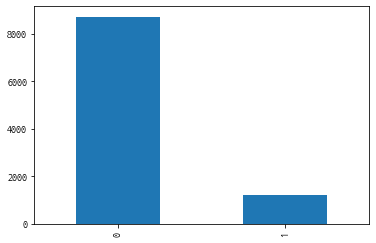

In [8]:
# termination 레이블 불균형 
df['termination'].value_counts().plot(kind='bar')

####
### **④ 데이터 전처리**

In [8]:
# 문자열 데이터 : class , sex, stop, npay, termination
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.00000,1584.0000,Y
1,E,F,24.0,1,N,N,16840.0000,2526.00000,6983.0000,N
2,F,F,32.0,1,N,N,15544.7334,2331.71001,6750.4666,N
3,D,M,18.0,1,N,N,4700.0000,0.00000,4502.0000,N
4,C,F,78.0,1,N,N,1361.7999,1173.99990,0.0000,N


##### <font color=blue> **[문제] replace 함수를 사용해서 'termination' 컬럼을 모델이 이해할수 있도록 Y --> 1 , N--> 0으로 변경하세요** </font>

In [9]:
# 대상 : df 데이터프레임 
# replace 함수 적용 대상 컬럼 : termination
# 방법1 :  replace( 'Y' , 1 ), replace( 'N' , 0 ) 각각 변경 적용
# 방법2 : df[ 'termination' ].replace( ['Y', 'N'] , [1, 0] ) 이렇게 한번에 적용


df[ 'termination' ] = df[ 'termination' ].replace( ['Y', 'N'] , [1, 0] )

In [10]:
# termination 컬럼에 대해 replace 함수 적용후 확인
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.00000,1584.0000,1
1,E,F,24.0,1,N,N,16840.0000,2526.00000,6983.0000,0
2,F,F,32.0,1,N,N,15544.7334,2331.71001,6750.4666,0
3,D,M,18.0,1,N,N,4700.0000,0.00000,4502.0000,0
4,C,F,78.0,1,N,N,1361.7999,1173.99990,0.0000,0


In [11]:
# 라벨인코더 임포트
from sklearn.preprocessing import LabelEncoder

##### <font color=blue> **[문제] df DataFrame에서 'npay' 컬럼을 모델이 이해할수 있도록 라벨인코딩하세요.** </font>

In [12]:
# 대상 : df 데이터프레임 
# 라벨인코더 대상 컬럼 : npay
# LabelEncoder() 함수를 le 정의 및 fit_transform 적용


le = LabelEncoder()
df[ 'npay' ] = le.fit_transform( df[ 'npay' ] )

In [13]:
# npay 컬럼에 대해 라벨인코더 적용후 확인
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,0,2640.0000,792.00000,1584.0000,1
1,E,F,24.0,1,N,0,16840.0000,2526.00000,6983.0000,0
2,F,F,32.0,1,N,0,15544.7334,2331.71001,6750.4666,0
3,D,M,18.0,1,N,0,4700.0000,0.00000,4502.0000,0
4,C,F,78.0,1,N,0,1361.7999,1173.99990,0.0000,0


In [15]:
# 나머지 문자열 컬럼들 
cal_cols = ['class', 'sex', 'stop']

##### <font color=blue> **[문제] 나머지 Object 컬럼에 대해 Pandas get_dummies 함수 활용하여 원핫인코딩하세요.** </font>

In [16]:
# 대상 : df 데이터프레임 
# 원핫인코딩 대상 컬럼 : 'class', 'sex', 'stop'
# Pandas get_dummies 함수 활용
# get_dummies 함수의 옵션으로 가변수 제거하는 drop_first=True 설정


df = pd.get_dummies(data=df, columns=cal_cols, drop_first=True)

In [17]:
# 기존 1개의 class 컬럼이  5개의 class_D, class_E, class_F, class_G, class_H 컬럼으로 원핫인코딩 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          8228 non-null   float64
 1   service      8228 non-null   int64  
 2   npay         8228 non-null   int32  
 3   avg_bill     8228 non-null   float64
 4   A_bill       8228 non-null   float64
 5   B_bill       8228 non-null   float64
 6   termination  8228 non-null   int64  
 7   class_D      8228 non-null   bool   
 8   class_E      8228 non-null   bool   
 9   class_F      8228 non-null   bool   
 10  class_G      8228 non-null   bool   
 11  class_H      8228 non-null   bool   
 12  sex_M        8228 non-null   bool   
 13  stop_Y       8228 non-null   bool   
dtypes: bool(7), float64(4), int32(1), int64(2)
memory usage: 474.2 KB


####
### **⑤ Train, Test  데이터셋 분할**

In [12]:
from sklearn.model_selection import train_test_split

##### <font color=blue> **[문제] df DataFrame에서 'termination' 컬럼을 제외한 나머지 정보를 X에 저장하세요.** </font>

In [19]:
# 대상 : df 데이터프레임 
# DataFrame drop 함수 활용
# 'termination' 컬럼 삭제
# DataFrame에서 values만 X에 저장



X = df.drop('termination', axis=1).values

##### <font color=blue> **[문제] df DataFrame에서 'termination' 컬럼을 y로 저장하세요.** </font>

In [20]:
# 대상 : df 데이터프레임
# DataFrame 'termination' 컬럼 사용
# DataFrame에서 values만 y에 저장



y = df['termination'].values

In [21]:
X.shape, y.shape

((8228, 13), (8228,))

#### Train , Test dataset 나누기

In [23]:
from sklearn.model_selection import train_test_split

##### <font color=blue> **[문제] Train dataset, Test dataset 나누세요.** </font>

In [24]:
# Train dataset, Test dataset 나누기 : train_test_split 함수 사용
# 입력 : X, y 
# Train : Test 비율 = 7: 3  --> test_size=0.3
# y Class 비율에 맞게 나주어 주세요 : stratify=y
# 여러번 수행해도 같은 결과 나오게 고정하기 : random_state=42 
# 결과 : X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    stratify=y,
                                                    random_state=42)

In [25]:
X_train.shape

(5759, 13)

In [26]:
y_train.shape

(5759,)

####
### **⑥ 데이터 정규화/스케일링(Normalizing/Scaling)**

In [27]:
# 숫자 분포 이루어진 컬럼 확인
df.tail()

,age,service,npay,avg_bill,A_bill,B_bill,termination,class_D,class_E,class_F,class_G,class_H,sex_M,stop_Y
8223,76.0,1,0,1860.0000,1716.000000,0.0000,0,False,False,False,False,False,True,False
8224,15.0,1,1,1296.0999,194.414985,643.1001,0,False,False,False,False,False,False,False
8225,12.0,1,0,13799.6666,2069.949990,10605.9266,0,False,False,False,True,False,True,False
8226,40.0,0,0,3140.0000,942.000000,1884.0000,1,False,False,False,False,False,False,False
8227,59.0,1,0,2436.9000,365.535000,1839.9000,0,False,False,False,False,False,False,False


In [29]:
from sklearn.preprocessing import StandardScaler

##### <font color=blue> **[문제] X_train과 X_test 데이터에 대해서 StandardScaler 적용하세요.** </font>

In [30]:
# StandardScaler 함수를 정의 : ss 저장
# X_train 데이터에 대해서는 fi_transform 적용
# X_test 데이터에 대해서는 transform 적용



ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [31]:
X_train[:2]

array([[ 0.77907132,  4.75702764, -0.36253853,  0.28352014,  0.2182524 ,
         0.8080494 , -0.60282636, -0.42526331,  3.23960028, -0.56886182,
        -0.12811595,  0.92679084, -0.1395438 ],
       [ 0.15466498, -1.54054998, -0.36253853, -0.4993926 ,  0.03443346,
        -0.43986501,  1.65885247, -0.42526331, -0.30868006, -0.56886182,
        -0.12811595,  0.92679084, -0.1395438 ]])

#### 
### **⑦ 딥러닝 심층신경망(DNN) 모델 구현**

### 라이브러리 임포트

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

#### 
### 하이퍼파라미터 설정 : batch_size, epochs

In [36]:
batch_size = 16
epochs = 20

#### 
### 모델 입력(features) 갯수 확인

In [37]:
X_train.shape

(5759, 13)

#### 
### 모델 출력(label) 갯수 확인

In [38]:
y_train.shape

(5759,)

#### 
### A. 이진분류 DNN모델 구성 

![hidden Layer](https://github.com/gzone2000/TEMP_TEST/raw/master/hidden_layer1.PNG)
+ [출처] https://subscription.packtpub.com/book/data/9781788995207/1/ch01lvl1sec03/deep-learning-intuition

##### <font color=blue> **[문제] 요구사항대로 Sequential 모델을 만들어 보세요.** </font>

In [39]:
# Sequential() 모델 정의 하고 model로 저장
# input layer는 input_shape=() 옵션을 사용한다.
# 13개 input layer
# unit 4개 hidden layer
# unit 3개 hidden layer 
# 1개 output layser : 이진분류


model = Sequential()
model.add(Dense(4, activation='relu', input_shape=(13,)))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

#### 
### 모델 확인

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              15 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75 (300.00 B)

 Trainable params: 75 (300.00 B)

 Non-trainable params: 0 (0.00 B)

#### 
### 모델 구성 -  과적합 방지

![dropout](https://github.com/gzone2000/TEMP_TEST/raw/master/dropout.PNG)
+ [출처] https://medium.com/@amarbudhiraja/https-medium-com-amarbudhiraja-learning-less-to-learn-better-dropout-in-deep-machine-learning-74334da4bfc5

In [41]:
model = Sequential()
model.add(Dense(4, activation='relu', input_shape=(13,)))
model.add(Dropout(0.3))
model.add(Dense(3, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

#### 
### 과적합 방지 모델 확인

In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 4)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              15 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 3)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75 (300.00 B)

 Trainable params: 75 (300.00 B)

 Non-trainable params: 0 (0.00 B)

#### 
### 모델 컴파일 – 이진 분류 모델

##### <font color=blue> **[문제] 아래 가이드대로 모델 컴파일하세요.** </font>
- 최적화 알고리즘 optimizer : 'adam'
- 로스 함수 : binary_crossentropy
- 메트릭 : accuracy

In [43]:
# 모델 compile
#   최적화 알고리즘 optimizer : 'adam'
#   로스 함수 : binary_crossentropy (1개의 출력으로 2개 분류해야 하므로)
#   메트릭 : accuracy


model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy']) 

- 모델 컴파일 – 다중 분류 모델 (Y값을 One-Hot-Encoding 한경우) <br>
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy']) 

- 모델 컴파일 – 다중 분류 모델  (Y값을 One-Hot-Encoding 하지 않은 경우) <br>
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

- 모델 컴파일 – 예측 모델
model.compile(optimizer='adam', loss='mse')

#### 
### 모델 학습

##### <font color=blue> **[문제] 요구사항대로 DNN 모델을 학습시키세요.** </font>
+ 모델 이름 : model
+ epoch : 10번
+ batch_size : 10번

In [44]:
# 앞쪽에서 정의된 모델 이름 : model
# Sequential 모델의 fit() 함수 사용
# @인자
### X, y : X_train, y_train
### validation_data=(X_test, y_test)
### epochs 10번
### batch_size 10번


model.fit(X_train, y_train, 
          validation_data=(X_test, y_test),
          epochs=10, 
          batch_size=10)

Epoch 1/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9002 - loss: 0.5234 - val_accuracy: 0.9008 - val_loss: 0.3335
Epoch 2/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9018 - loss: 0.3735 - val_accuracy: 0.9008 - val_loss: 0.2883
Epoch 3/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9049 - loss: 0.3261 - val_accuracy: 0.9008 - val_loss: 0.2589
Epoch 4/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9039 - loss: 0.2981 - val_accuracy: 0.9008 - val_loss: 0.2343
Epoch 5/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9003 - loss: 0.2737 - val_accuracy: 0.9008 - val_loss: 0.2200
Epoch 6/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8991 - loss: 0.2670 - val_accuracy: 0.9008 - val_loss: 0.2081
Epoch 7/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8999 - loss: 0.2565 - val_accuracy: 0.9008 - val_loss: 0.1985
Epoch 8/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8944 - loss: 0.2592 - val_accuracy: 0.

#### 
### B. 다중 분류 DNN 구성
+ 13개 input layer
+ unit 5개 hidden layer
+ dropout
+ unit 4개 hidden layer 
+ dropout
+ 2개 output layser : 이진분류

![다중분류](https://github.com/gzone2000/TEMP_TEST/raw/master/hidden_layer2.PNG)
+ [출처] https://www.educba.com/dnn-neural-network/

In [45]:
# 13개 input layer
# unit 5개 hidden layer
# dropout
# unit 4개 hidden layer 
# dropout
# 2개 output layser : 다중분류

model = Sequential()
model.add(Dense(5, activation='relu', input_shape=(13,)))
model.add(Dropout(0.3))
model.add(Dense(4, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

#### 
### 모델 확인

In [46]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 5)                   │              70 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 5)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │              10 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 104 (416.00 B)

 Trainable params: 104 (416.00 B)

 Non-trainable params: 0 (0.00 B)

#### 
### 모델 컴파일 – 다중 분류 모델

In [48]:
# loss 함수 : sparse_categorical_crossentropy
# 분류 모델 & 2개의 출력 : categorical_crossentropy
# y레이블을 원핫인코딩해야 하므로 sparse_categorical_crossentropy

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy']) 

#### 
### 모델 학습

In [49]:
history = model.fit(X_train, y_train, 
          validation_data=(X_test, y_test),
          epochs=20, 
          batch_size=16)

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6445 - loss: 0.6762 - val_accuracy: 0.9008 - val_loss: 0.3012
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9032 - loss: 0.3352 - val_accuracy: 0.9024 - val_loss: 0.2101
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9214 - loss: 0.2629 - val_accuracy: 0.9372 - val_loss: 0.1791
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9213 - loss: 0.2643 - val_accuracy: 0.9494 - val_loss: 0.1671
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9284 - loss: 0.2293 - val_accuracy: 0.9554 - val_loss: 0.1611
Epoch 6/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9334 - loss: 0.2153 - val_accuracy: 0.9579 - val_loss: 0.1546
Epoch 7/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9378 - loss: 0.1999 - val_accuracy: 0.9619 - val_loss: 0.1514
Epoch 8/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9292 - loss: 0.2202 - val_accuracy: 0.

#### 
### Callback : 조기종료, 모델 저장

In [50]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [51]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', 
                           verbose=1, patience=5)

In [53]:
check_point = ModelCheckpoint('best_model.keras', verbose=1,
                              monitor='val_loss', mode='min', 
                              save_best_only=True)

#### 
### 모델 학습

In [54]:
history = model.fit(x=X_train, y=y_train, 
          epochs=50 , batch_size=20,
          validation_data=(X_test, y_test), 
          verbose=1,
          callbacks=[early_stop, check_point])

Epoch 1/50
284/288 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9390 - loss: 0.1869
Epoch 1: val_loss improved from inf to 0.12931, saving model to best_model.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9390 - loss: 0.1869 - val_accuracy: 0.9635 - val_loss: 0.1293
Epoch 2/50
283/288 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9454 - loss: 0.1671
Epoch 2: val_loss improved from 0.12931 to 0.12753, saving model to best_model.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9453 - loss: 0.1673 - val_accuracy: 0.9631 - val_loss: 0.1275
Epoch 3/50
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9352 - loss: 0.1977
Epoch 3: val_loss did not improve from 0.12753
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9352 - loss: 0.1977 - val_accuracy: 0.9623 - val_loss: 0.1277
Epoch 4/50
257/288 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9463 - loss: 0.1691
Epoch 4: val_loss did not improve from 0.12753
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - ac

#### 
### 모델 성능 평가

In [58]:
losses = pd.DataFrame(model.history.history)

In [59]:
losses.head()

,accuracy,loss,val_accuracy,val_loss
0,0.938705,0.184295,0.963548,0.129306
1,0.940441,0.179281,0.963143,0.127532
2,0.941657,0.183797,0.962333,0.127675
3,0.944435,0.182964,0.962333,0.127924
4,0.946518,0.179430,0.963143,0.126590


+ 성능 시각화

<Axes: >

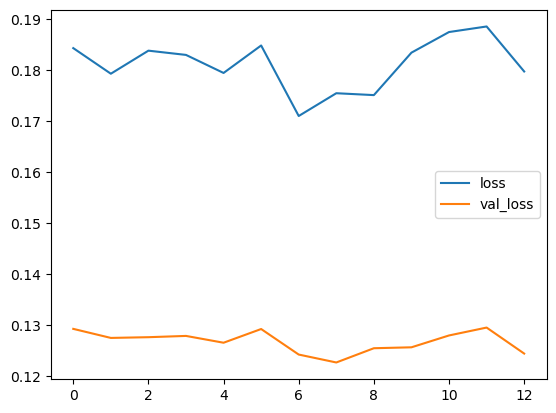

In [60]:
losses[['loss','val_loss']].plot()

<Axes: >

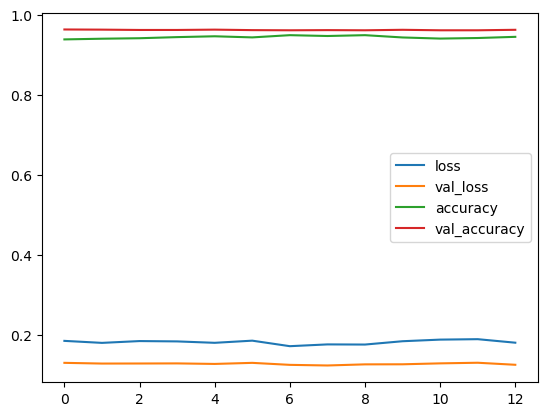

In [61]:
losses[['loss','val_loss', 'accuracy','val_accuracy']].plot()

##### <font color=blue> **[문제] 아래 가이드대로 성능 그래프를 그리세요** </font>
1. matplotlib의 plot 함수를 사용하여 모델의 accuracy와 val_accuracy 그리세요.
2. 타이틀 : Accuracy
3. x레이블 : Epochs
4. y레이블 : Accuracy
5. 범례 표시 : ['accuarcy', 'val_accuarcy']

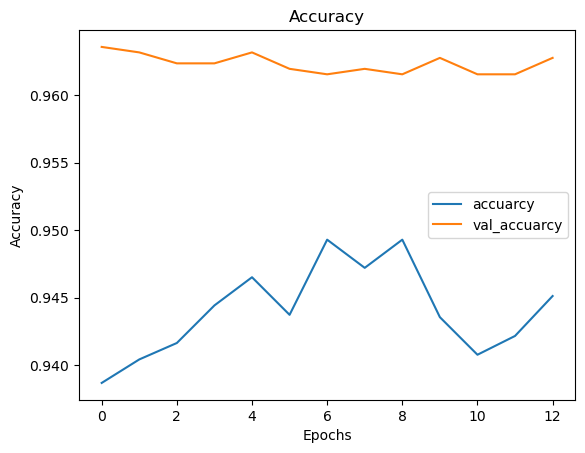

In [65]:
# matplotlib의 plot 함수를 사용
# 1. 모델의 accuracy와 val_accuracy 성능 --> history.history['accuracy'] , history.history['val_accuracy']
# 2. 타이틀 : Accuracy --> title('Accuracy')
# 3. x레이블 : Epochs --> xlabel('Epochs')
# 4. y레이블 : Accuracy --> ylabel('Accuracy')
# 5. 범례 표시 --> legend(['accuarcy', 'val_accuarcy'])

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['accuarcy', 'val_accuarcy'])

# 
# **배운 내용 정리**
1. 딥러닝 심층신경망(DNN) 모델 프로세스
 + 데이터 가져오기
 + 데이터 전처리
 + Train, Test 데이터셋 분할
 + 데이터 정규화
 + DNN 딥러닝 모델
